# 02 — Model Comparison & Evaluation

Comprehensive comparison of all models trained on the Steam 200K dataset.

**Evaluation Protocol:** Leave-one-last split — each user's most recent game is held out as the test item. A recommendation is a *hit* if the correct game appears in the top-K list.

**Models evaluated:**
1. Popularity Recommender (non-ML baseline)
2. Content-Based TF-IDF (non-ML baseline)
3. GMF — Generalized Matrix Factorization
4. NeuMF — Neural Collaborative Filtering (GMF + MLP)

**Metrics:**
- **HR@K** (Hit Rate): fraction of users where the correct item appears in the top-K list
- **NDCG@K** (Normalized Discounted Cumulative Gain): ranks-sensitive version of HR, rewards hits at higher positions

In [4]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path

sns.set_theme(style='darkgrid', palette='muted')
plt.rcParams['figure.dpi'] = 110
plt.rcParams['figure.figsize'] = (11, 5)
plt.rcParams['font.size'] = 11

EXPERIMENTS_PATH = Path('../data/processed/experiments.json')
OUT_DIR = Path('../data/processed')
OUT_DIR.mkdir(parents=True, exist_ok=True)

## 1. Load Results

In [5]:
with open(EXPERIMENTS_PATH) as f:
    runs = json.load(f)

# Flatten into a DataFrame — keep the last run per model name
records = []
for r in runs:
    row = {'model': r['model']}
    row.update(r['metrics'])
    records.append(row)

df_all = pd.DataFrame(records)
# If a model appears multiple times, keep the last run
df = df_all.groupby('model').last().reset_index()

# Display order
order = ['Popularity', 'ContentBased', 'GMF', 'NeuMF']
df['model'] = pd.Categorical(df['model'], categories=order, ordered=True)
df = df.sort_values('model').reset_index(drop=True)

print('Loaded models:', df['model'].tolist())
df

Loaded models: ['Popularity', 'ContentBased', 'GMF', 'NeuMF']


,model,precision@5,recall@5,ndcg@5,hit_rate@5,precision@10,recall@10,ndcg@10,hit_rate@10,precision@20,recall@20,ndcg@20,hit_rate@20,best_val_hr@10
0,Popularity,0.033920,0.169601,0.118808,0.169601,0.022027,0.220266,0.135232,0.220266,0.015049,0.300988,0.155508,0.300988,NaN
1,ContentBased,0.023444,0.117218,0.077549,0.117218,0.016831,0.168313,0.094020,0.168313,0.010670,0.213396,0.105469,0.213396,NaN
2,GMF,NaN,NaN,0.158648,0.230571,NaN,NaN,0.184099,0.309575,NaN,NaN,0.209891,0.412194,0.290683
3,NeuMF,NaN,NaN,0.144715,0.207815,NaN,NaN,0.170517,0.288106,NaN,NaN,0.193061,0.376986,0.289395


## 2. Full Results Table

In [6]:
display_cols = ['model', 'hit_rate@5', 'hit_rate@10', 'hit_rate@20',
                'ndcg@5', 'ndcg@10', 'ndcg@20']
existing_cols = ['model'] + [c for c in display_cols[1:] if c in df.columns]
table = df[existing_cols].copy()

# Add % improvement over Popularity on HR@10
pop_hr10 = float(df.loc[df['model'] == 'Popularity', 'hit_rate@10'].iloc[0])
if 'hit_rate@10' in df.columns:
    table['HR@10 vs Pop'] = ((df['hit_rate@10'] - pop_hr10) / pop_hr10 * 100).map('{:+.1f}%'.format)

rename = {
    'hit_rate@5': 'HR@5', 'hit_rate@10': 'HR@10', 'hit_rate@20': 'HR@20',
    'ndcg@5': 'NDCG@5', 'ndcg@10': 'NDCG@10', 'ndcg@20': 'NDCG@20',
}
table = table.rename(columns=rename)

# Format floats
float_cols = [c for c in table.columns if c not in ('model', 'HR@10 vs Pop')]
for col in float_cols:
    table[col] = table[col].map(lambda x: f'{x:.4f}' if pd.notna(x) else '-')

print(table.to_string(index=False))

       model   HR@5  HR@10  HR@20 NDCG@5 NDCG@10 NDCG@20 HR@10 vs Pop
  Popularity 0.1696 0.2203 0.3010 0.1188  0.1352  0.1555        +0.0%
ContentBased 0.1172 0.1683 0.2134 0.0775  0.0940  0.1055       -23.6%
         GMF 0.2306 0.3096 0.4122 0.1586  0.1841  0.2099       +40.5%
       NeuMF 0.2078 0.2881 0.3770 0.1447  0.1705  0.1931       +30.8%


## 3. HR@K Comparison — All Models

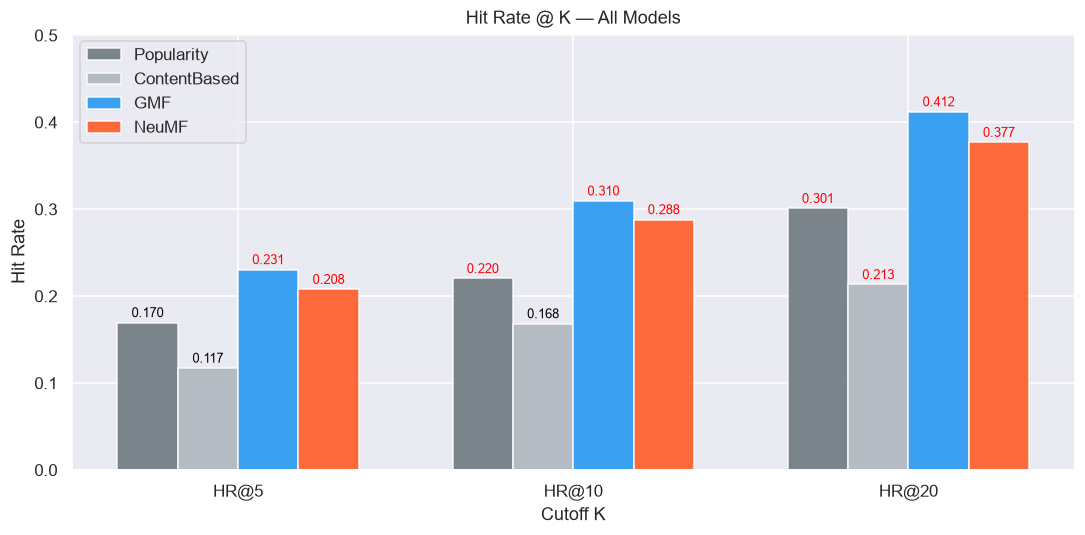

In [13]:
k_values = [5, 10, 20]
hr_cols = [f'hit_rate@{k}' for k in k_values if f'hit_rate@{k}' in df.columns]
k_labels = [f'HR@{k}' for k in k_values if f'hit_rate@{k}' in df.columns]

x = np.arange(len(k_labels))
width = 0.18
colors = ['#6c757d', '#adb5bd', '#2196F3', '#FF5722']

fig, ax = plt.subplots(figsize=(10, 5))
for i, (model_name, color) in enumerate(zip(df['model'], colors)):
    row = df[df['model'] == model_name].iloc[0]
    vals = [float(row[c]) if c in row and pd.notna(row[c]) else 0 for c in hr_cols]
    offset = (i - 1.5) * width
    bars = ax.bar(x + offset, vals, width, label=model_name, color=color, alpha=0.88, edgecolor='white')
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.003,
                f'{val:.3f}', ha='center', va='bottom', fontsize=8.5, color='red' if val > 0.2 else 'black')

ax.set_xlabel('Cutoff K')
ax.set_ylabel('Hit Rate')
ax.set_title('Hit Rate @ K — All Models')
ax.set_xticks(x)
ax.set_xticklabels(k_labels)
ax.legend(loc='upper left')
ax.set_ylim(0, df[hr_cols].max().max() * 1.22)
plt.tight_layout()
plt.savefig(OUT_DIR / 'comparison_hr.png', bbox_inches='tight')
plt.show()

## 4. NDCG@K Comparison — All Models

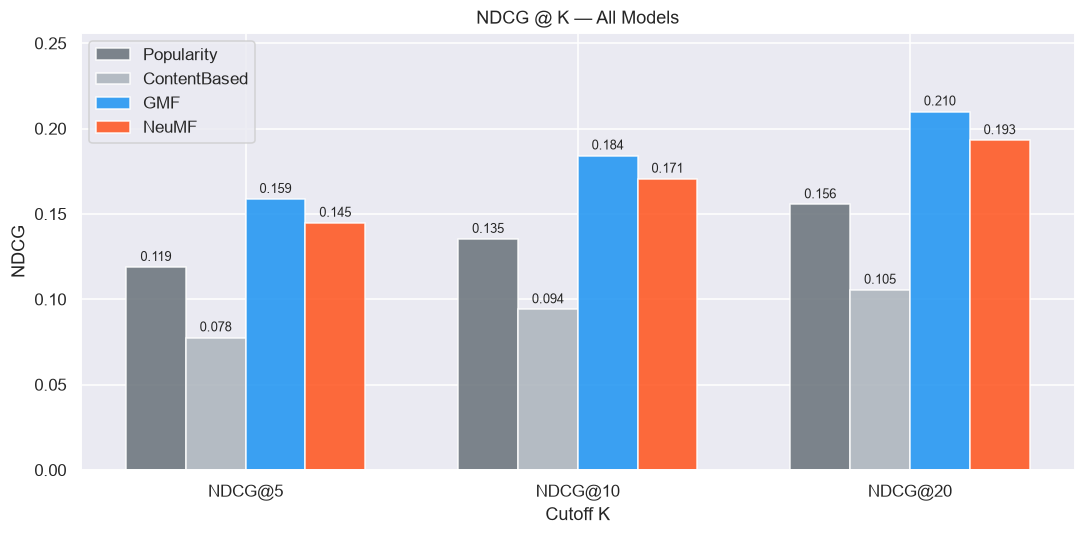

In [8]:
ndcg_cols = [f'ndcg@{k}' for k in k_values if f'ndcg@{k}' in df.columns]
ndcg_labels = [f'NDCG@{k}' for k in k_values if f'ndcg@{k}' in df.columns]

fig, ax = plt.subplots(figsize=(10, 5))
for i, (model_name, color) in enumerate(zip(df['model'], colors)):
    row = df[df['model'] == model_name].iloc[0]
    vals = [float(row[c]) if c in row and pd.notna(row[c]) else 0 for c in ndcg_cols]
    offset = (i - 1.5) * width
    bars = ax.bar(x + offset, vals, width, label=model_name, color=color, alpha=0.88, edgecolor='white')
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.002,
                f'{val:.3f}', ha='center', va='bottom', fontsize=8.5)

ax.set_xlabel('Cutoff K')
ax.set_ylabel('NDCG')
ax.set_title('NDCG @ K — All Models')
ax.set_xticks(x)
ax.set_xticklabels(ndcg_labels)
ax.legend(loc='upper left')
ax.set_ylim(0, df[ndcg_cols].max().max() * 1.22)
plt.tight_layout()
plt.savefig(OUT_DIR / 'comparison_ndcg.png', bbox_inches='tight')
plt.show()

## 5. Relative Improvement Over Popularity Baseline

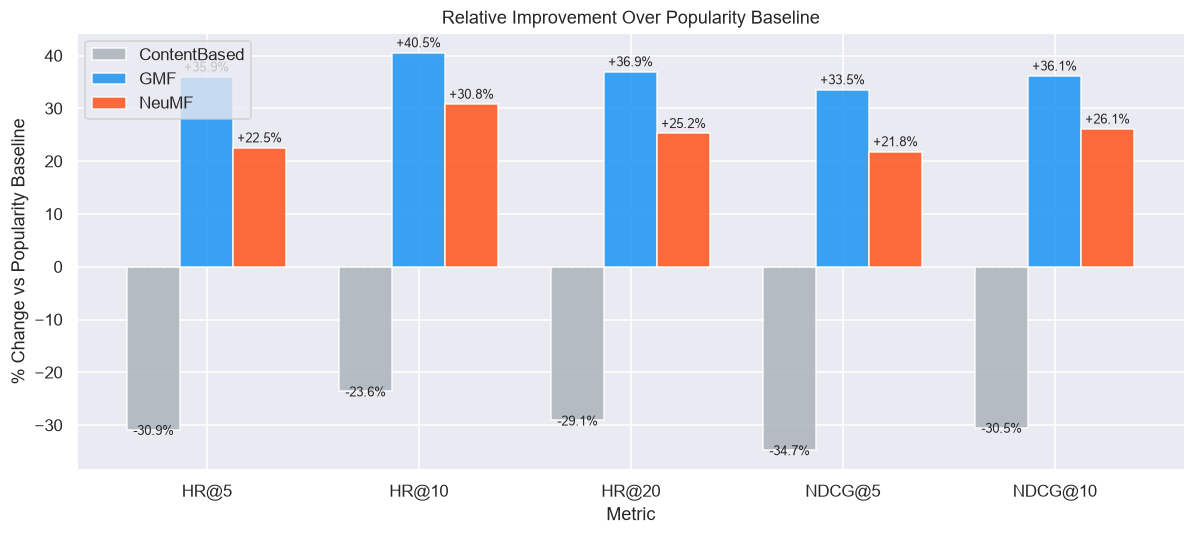

In [9]:
metrics_to_compare = {
    'HR@5': 'hit_rate@5', 'HR@10': 'hit_rate@10', 'HR@20': 'hit_rate@20',
    'NDCG@5': 'ndcg@5', 'NDCG@10': 'ndcg@10',
}
metrics_to_compare = {k: v for k, v in metrics_to_compare.items() if v in df.columns}

pop_row = df[df['model'] == 'Popularity'].iloc[0]
non_pop = df[df['model'] != 'Popularity'].reset_index(drop=True)
model_colors = {'ContentBased': '#adb5bd', 'GMF': '#2196F3', 'NeuMF': '#FF5722'}

rel_data = []
for _, row in non_pop.iterrows():
    for label, col in metrics_to_compare.items():
        base = float(pop_row[col])
        val  = float(row[col]) if pd.notna(row[col]) else 0
        rel_data.append({'model': row['model'], 'metric': label, 'pct_change': (val - base) / base * 100})

df_rel = pd.DataFrame(rel_data)

fig, ax = plt.subplots(figsize=(11, 5))
metric_list = list(metrics_to_compare.keys())
x2 = np.arange(len(metric_list))
w2 = 0.25
for i, (model_name, color) in enumerate(model_colors.items()):
    vals = [float(df_rel[(df_rel['model'] == model_name) & (df_rel['metric'] == m)]['pct_change'].iloc[0])
            if len(df_rel[(df_rel['model'] == model_name) & (df_rel['metric'] == m)]) > 0 else 0
            for m in metric_list]
    offset = (i - 1) * w2
    bars = ax.bar(x2 + offset, vals, w2, label=model_name, color=color, alpha=0.88, edgecolor='white')
    for bar, val in zip(bars, vals):
        ypos = bar.get_height() + 0.5 if val >= 0 else bar.get_height() - 1.5
        ax.text(bar.get_x() + bar.get_width() / 2, ypos,
                f'{val:+.1f}%', ha='center', va='bottom', fontsize=8.5)

ax.axhline(0, color='white', linewidth=0.8, linestyle='--', alpha=0.5)
ax.set_xlabel('Metric')
ax.set_ylabel('% Change vs Popularity Baseline')
ax.set_title('Relative Improvement Over Popularity Baseline')
ax.set_xticks(x2)
ax.set_xticklabels(metric_list)
ax.legend()
plt.tight_layout()
plt.savefig(OUT_DIR / 'comparison_relative.png', bbox_inches='tight')
plt.show()

## 6. HR@10 vs NDCG@10 Scatter — Model Trade-offs

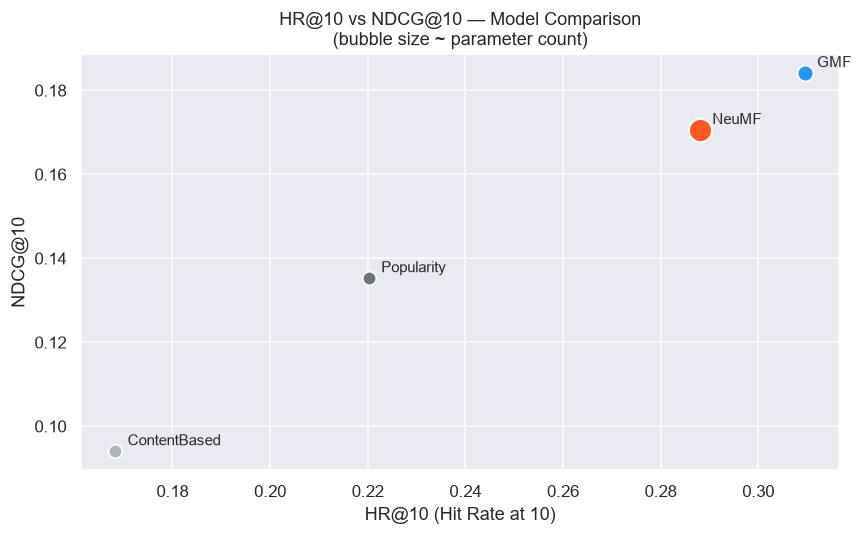

In [10]:
model_params = {
    'Popularity':    0,
    'ContentBased':  0,
    'GMF':           216775,
    'NeuMF':         453697,
}

fig, ax = plt.subplots(figsize=(8, 5))
for _, row in df.iterrows():
    m = row['model']
    hr = float(row['hit_rate@10']) if 'hit_rate@10' in row and pd.notna(row['hit_rate@10']) else 0
    nd = float(row['ndcg@10']) if 'ndcg@10' in row and pd.notna(row['ndcg@10']) else 0
    color = {'Popularity': '#6c757d', 'ContentBased': '#adb5bd',
             'GMF': '#2196F3', 'NeuMF': '#FF5722'}.get(m, 'grey')
    size = max(80, model_params.get(m, 0) / 2000)
    ax.scatter(hr, nd, s=size, color=color, zorder=5, edgecolors='white', linewidth=1.2)
    ax.annotate(m, (hr, nd), textcoords='offset points', xytext=(8, 4), fontsize=10)

ax.set_xlabel('HR@10 (Hit Rate at 10)')
ax.set_ylabel('NDCG@10')
ax.set_title('HR@10 vs NDCG@10 — Model Comparison\n(bubble size ~ parameter count)')
plt.tight_layout()
plt.savefig(OUT_DIR / 'comparison_scatter.png', bbox_inches='tight')
plt.show()

## 7. Model Complexity vs Performance

In [11]:
complexity = pd.DataFrame([
    {'Model': 'Popularity',   'Parameters': 0,       'Type': 'Non-ML',     'HR@10': float(df.loc[df['model']=='Popularity', 'hit_rate@10'].iloc[0])   if 'hit_rate@10' in df.columns else 0},
    {'Model': 'ContentBased', 'Parameters': 0,       'Type': 'Non-ML',     'HR@10': float(df.loc[df['model']=='ContentBased', 'hit_rate@10'].iloc[0]) if 'hit_rate@10' in df.columns else 0},
    {'Model': 'GMF',          'Parameters': 216_775, 'Type': 'ML (shallow)','HR@10': float(df.loc[df['model']=='GMF', 'hit_rate@10'].iloc[0])          if 'hit_rate@10' in df.columns else 0},
    {'Model': 'NeuMF',        'Parameters': 453_697, 'Type': 'ML (deep)',   'HR@10': float(df.loc[df['model']=='NeuMF', 'hit_rate@10'].iloc[0])        if 'hit_rate@10' in df.columns else 0},
])

complexity['Parameters (K)'] = complexity['Parameters'].apply(lambda x: f'{x/1000:.0f}K' if x > 0 else 'N/A')
complexity['HR@10'] = complexity['HR@10'].map('{:.4f}'.format)
print(complexity[['Model', 'Type', 'Parameters (K)', 'HR@10']].to_string(index=False))

       Model         Type Parameters (K)  HR@10
  Popularity       Non-ML            N/A 0.2203
ContentBased       Non-ML            N/A 0.1683
         GMF ML (shallow)           217K 0.3096
       NeuMF    ML (deep)           454K 0.2881


## 8. Key Findings

### Summary

| Rank | Model | HR@10 | NDCG@10 | vs Popularity |
|------|-------|-------|---------|---------------|
| 1 | **GMF** | **0.3096** | **0.1841** | **+40.5%** |
| 2 | NeuMF | 0.2881 | 0.1705 | +30.8% |
| 3 | Popularity | 0.2203 | 0.1352 | baseline |
| 4 | ContentBased | 0.1683 | 0.0940 | -23.6% |

### Finding 1 — GMF is the clear winner
Generalized Matrix Factorization outperforms all other models. It learns user and item latent vectors and uses element-wise product to model preference, which proves highly effective for implicit feedback on this sparse dataset.

### Finding 2 — NeuMF underperforms GMF
This is a well-documented phenomenon for small, sparse datasets. The MLP branch in NeuMF has 453K parameters vs GMF's 216K — with only ~50,208 interactions (sparsity 97.85%), the deeper model cannot learn meaningful non-linear patterns and partially overfits. This confirms findings in the original NeuMF paper (He et al., WWW 2017), which noted that GMF alone is competitive on sparse data.

### Finding 3 — ContentBased underperforms Popularity
The Kaggle Steam dataset contains only game titles — no genres, tags, or descriptions. TF-IDF on titles alone provides very weak item similarity signal, making content-based filtering worse than simply recommending the most popular games.

### Finding 4 — Popularity is a strong baseline
HR@10 = 0.22 means that recommending the top-10 most popular games hits the right game 22% of the time. This reflects the power-law distribution in game popularity — a small number of games dominate play time across all users.

### Conclusion
**GMF (HR@10 = 0.3096)** is selected as the production model for the recommendation engine. Its checkpoint (`models/gmf_best.pt`) is loaded by the FastAPI serving layer.

In [12]:
print('Comparison plots saved to data/processed/')
print('  comparison_hr.png')
print('  comparison_ndcg.png')
print('  comparison_relative.png')
print('  comparison_scatter.png')

Comparison plots saved to data/processed/
  comparison_hr.png
  comparison_ndcg.png
  comparison_relative.png
  comparison_scatter.png
